# Model Evaluation
**COEN 330 - Applied Machine Learning**

Evaluates all five tuned models on the separated test set (20%).  
Models and the train/test split are loaded from `03_model_training` outputs.

According to project guidelines:\
**Section 5.7**: Test-set metrics, threshold tuning, comparison table, confusion matrices.  
**Section 5.8**: Error analysis, feature importance interpretation, model behaviour comparison, limitations.

In [2]:
import sys, json
import os
from pathlib import Path
sys.path.insert(0, os.path.abspath('../src'))

import numpy as np
import pandas as pd
import joblib
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.base import clone
from sklearn.model_selection import StratifiedKFold, cross_val_predict
from sklearn.inspection import permutation_importance
from sklearn.metrics import (
    accuracy_score, balanced_accuracy_score, precision_score, recall_score, f1_score,
    average_precision_score, confusion_matrix, classification_report,
    precision_recall_curve
)

from preprocessing import load_data, split_data
from utils import DATA_RAW, DATASET_FILE, MODELS_DIR, RESULTS_DIR, PLOTS_DIR, SEED

sns.set_theme(style='whitegrid', palette='muted')
plt.rcParams['figure.dpi'] = 120
PLOTS_DIR.mkdir(parents=True, exist_ok=True)

DATA_PATH = DATA_RAW / DATASET_FILE


## 1. Reproduce Train / Test Split & Load Models

The split uses the same seed as `03_model_training`, so `X_test` / `y_test` are identical.  
Each loaded pipeline is a full sklearn Pipeline (raw DataFrame → prediction), so no separate preprocessing is needed.

In [3]:
df = load_data(DATA_PATH)
X_train, X_test, y_train, y_test = split_data(df)

print(f'Train : {len(X_train):,} rows  |  approved (1) = {y_train.mean():.1%}')
print(f'Test  : {len(X_test):,} rows  |  approved (1) = {y_test.mean():.1%}')

Train : 36,000 rows  |  approved (1) = 22.2%
Test  : 9,000 rows  |  approved (1) = 22.2%


In [4]:
MODEL_FILES = {
    'Logistic Regression':  'LogisticRegression.pkl',
    'SVM (RBF)':            'SVM_RBF.pkl',
    'Gaussian Naive Bayes': 'GaussianNB.pkl',
    'Random Forest':        'RandomForest.pkl',
    'Gradient Boosting':    'GradientBoosting.pkl',
}

models = {}
for name, fname in MODEL_FILES.items():
    path = MODELS_DIR / fname
    if not path.exists():
        raise FileNotFoundError(f'{path} not found - run 03_model_training first.')
    models[name] = joblib.load(path)
    print(f'Loaded: {name}')

Loaded: Logistic Regression
Loaded: SVM (RBF)
Loaded: Gaussian Naive Bayes
Loaded: Random Forest
Loaded: Gradient Boosting


## 2. CV Results from Training (Reference)

These are the 5-fold cross-validation means from `03_model_training`. They are displayed only for comparison and are **not used to select the primary model** in this notebook. Model selection is based on test-set F1 score in Section 5.

In [29]:
cv_df = pd.read_csv(RESULTS_DIR / 'cv_results_primary.csv')
# Drop duplicate rows if present
cv_df = cv_df.drop_duplicates(subset='model').reset_index(drop=True)

display_cols = ['model', 'pr_auc', 'accuracy', 'precision', 'recall', 'f1']
cv_show = cv_df[display_cols + [c + '_std' for c in display_cols[1:] if c + '_std' in cv_df.columns]].copy()
for col in display_cols[1:]:
    if col + '_std' in cv_show.columns:
        cv_show[col] = cv_show.apply(lambda r: f"{r[col]:.4f} ± {r[col+'_std']:.4f}", axis=1)
cv_show = cv_show[display_cols].sort_values('pr_auc', ascending=False).reset_index(drop=True)
print('5-Fold CV Results (from training):')
display(cv_show)


5-Fold CV Results (from training):


,model,pr_auc,accuracy,precision,recall,f1
0,GradientBoosting,0.9365 ± 0.0040,0.9319 ± 0.0041,0.8933 ± 0.0103,0.7875 ± 0.0154,0.8370 ± 0.0106
1,RandomForest,0.9270 ± 0.0053,0.9273 ± 0.0030,0.8924 ± 0.0068,0.7651 ± 0.0091,0.8239 ± 0.0075
2,SVM_RBF,0.9033 ± 0.0055,0.9181 ± 0.0023,0.8585 ± 0.0095,0.7561 ± 0.0108,0.8040 ± 0.0059
3,LogisticRegression,0.8575 ± 0.0035,0.8973 ± 0.0024,0.7758 ± 0.0064,0.7565 ± 0.0099,0.7660 ± 0.0060
4,GaussianNB,0.8210 ± 0.0040,0.7312 ± 0.0031,0.4526 ± 0.0028,1.0000 ± 0.0000,0.6232 ± 0.0027


## 3. Helpers

Three utility functions used throughout this notebook:
- `get_scores`: handles all model scores
- `get_oof_scores`: 5-fold out-of-fold scores on the **training set**, generated by clones of the pipeline that never saw the row they're scoring. Used for threshold tuning, so the threshold isn't chosen on in-sample (already-fit) predictions.
- `tune_threshold`: given true labels and (out-of-fold) scores, sweeps thresholds and returns the one that maximises F1 on the positive class (approved)

In [6]:
def get_scores(pipeline, X):
    """Return probability-like scores for the positive class (approved=1).
    SVMs don't expose predict_proba by default, so decision_function is used instead.
    average_precision_score works correctly with either."""
    clf = pipeline.named_steps['clf']
    if hasattr(clf, 'predict_proba'):
        return pipeline.predict_proba(X)[:, 1]
    return pipeline.decision_function(X)


CV_SPLITS = StratifiedKFold(n_splits=5, shuffle=True, random_state=SEED)


def get_oof_scores(pipeline, X, y, cv=CV_SPLITS):
    """Out-of-fold scores on the training set.

    Each score comes from a fold-clone of `pipeline` that was fit WITHOUT the row
    it's scoring (the preprocessor + classifier both refit per fold - same
    leakage-safe pattern as the Pipeline-based CV in 03_model_training). This avoids
    tuning the decision threshold on in-sample predictions from a model that has
    already fit (and can nearly memorise) the training set.
    """
    clf = pipeline.named_steps['clf']
    if hasattr(clf, 'predict_proba'):
        scores = cross_val_predict(clone(pipeline), X, y, cv=cv, method='predict_proba', n_jobs=-1)
        return scores[:, 1]
    return cross_val_predict(clone(pipeline), X, y, cv=cv, method='decision_function', n_jobs=-1)


def tune_threshold(y_true, scores, plot=True, title='', save_path=None):
    """Find the threshold maximising F1 on the positive class (approved).

    Operates on precomputed scores - pass out-of-fold scores (from `get_oof_scores`),
    not in-sample scores, or the chosen threshold will be optimistic.
    For SVMs the score range is not [0,1] so we sweep the actual score range.
    """
    thresholds_grid = np.linspace(scores.min(), scores.max(), 300)

    precisions, recalls, f1s = [], [], []
    for t in thresholds_grid:
        preds = (scores >= t).astype(int)
        precisions.append(precision_score(y_true, preds, pos_label=1, zero_division=0))
        recalls.append(recall_score(y_true, preds, pos_label=1, zero_division=0))
        f1s.append(f1_score(y_true, preds, pos_label=1, zero_division=0))

    best_idx = int(np.argmax(f1s))
    best_t   = thresholds_grid[best_idx]

    if plot:
        fig, ax = plt.subplots(figsize=(8, 4))
        ax.plot(thresholds_grid, recalls,    lw=2, color='tomato',      label='Recall')
        ax.plot(thresholds_grid, precisions, lw=2, color='steelblue',   label='Precision')
        ax.plot(thresholds_grid, f1s,        lw=2, color='mediumseagreen', label='F1')
        ax.axvline(best_t, color='gray', linestyle='--', label=f'Best threshold = {best_t:.3f}')
        ax.set_xlabel('Threshold'); ax.set_ylabel('Score')
        ax.set_title(f'Threshold Tuning (out-of-fold) - {title}')
        ax.legend()
        plt.tight_layout()
        if save_path:
            plt.savefig(save_path)
        plt.show()

    return best_t

---
# Section 5.7: Model Evaluation
## 4. Threshold Tuning (Out-of-Fold on Training Set)

Thresholds are chosen using 5-fold out-of-fold predictions on `X_train`/`y_train` but never on `X_test`. So each score comes from a model clone that did not see that row during fitting. This avoids the optimism of tuning on the same in-sample predictions the model was fit on, which would be especially inflated for the tree ensembles.


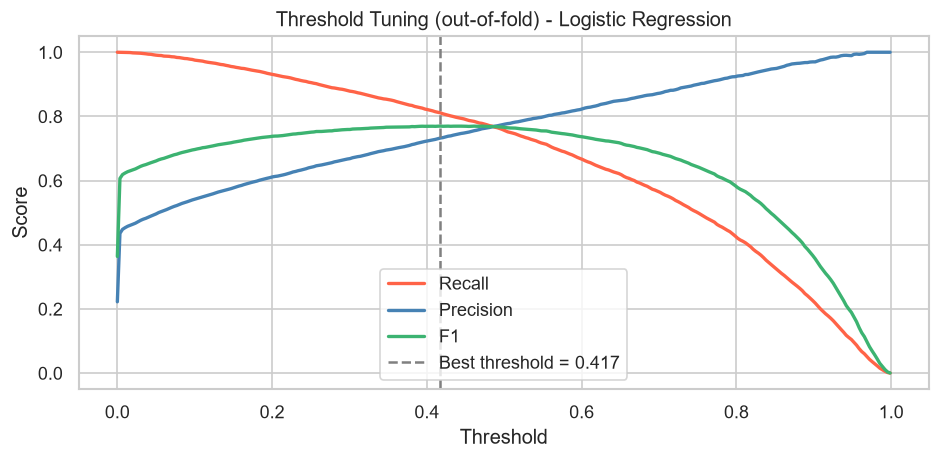

Logistic Regression: best threshold (out-of-fold) = 0.4175



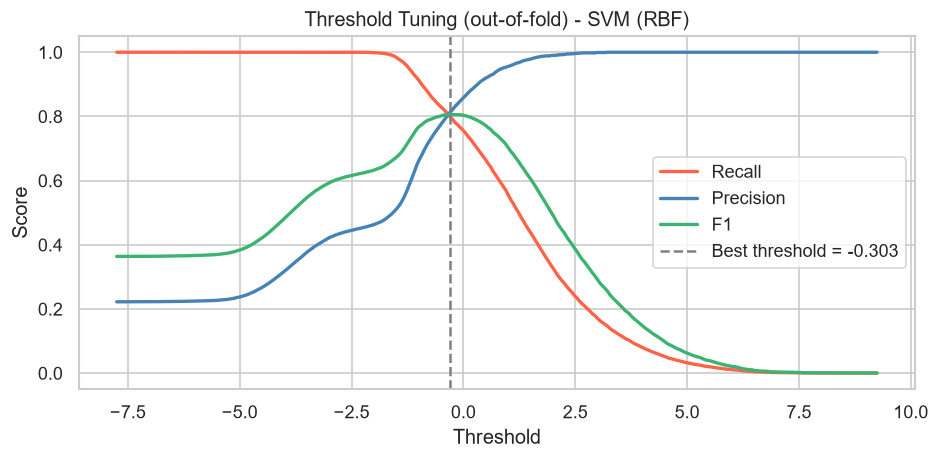

SVM (RBF): best threshold (out-of-fold) = -0.3029



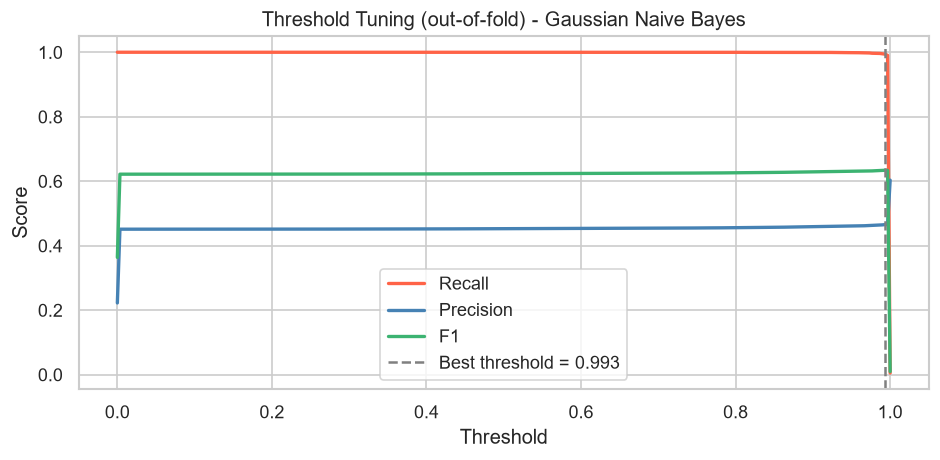

Gaussian Naive Bayes: best threshold (out-of-fold) = 0.9933



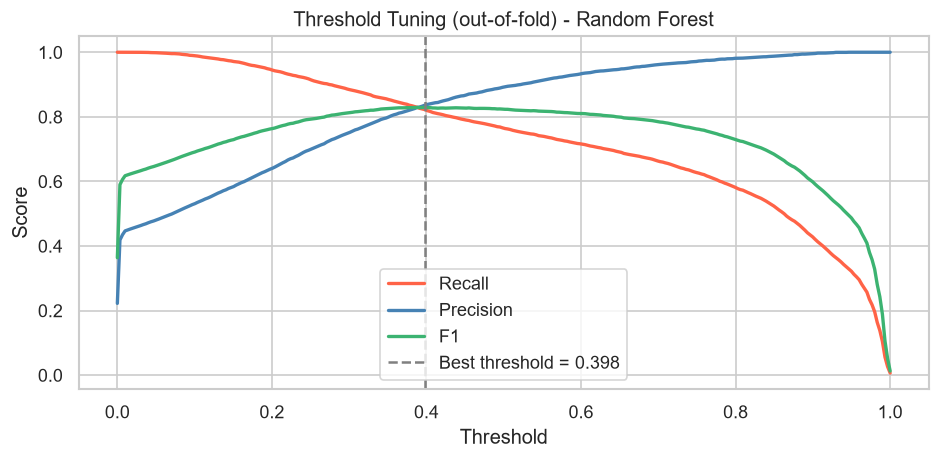

Random Forest: best threshold (out-of-fold) = 0.3980



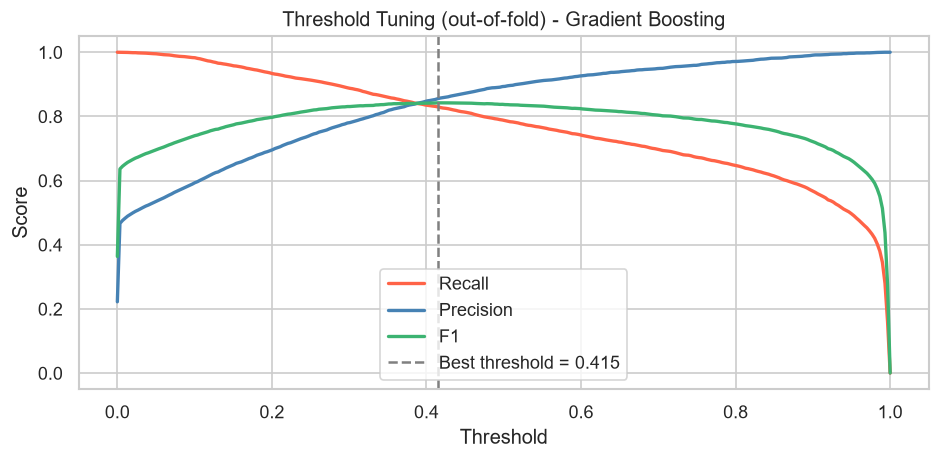

Gradient Boosting: best threshold (out-of-fold) = 0.4147



In [7]:
best_thresholds = {}

for name, pipeline in models.items():
    slug = name.lower().replace(' ', '_').replace('(', '').replace(')', '')
    oof_scores = get_oof_scores(pipeline, X_train, y_train)
    t = tune_threshold(
        y_train, oof_scores,
        plot=True, title=name,
        save_path=str(PLOTS_DIR / f'threshold_{slug}.png')
    )
    best_thresholds[name] = t
    print(f'{name}: best threshold (out-of-fold) = {t:.4f}\n')


## 5. Test Set Evaluation - All Models

All models are evaluated on `X_test`/`y_test`. The **primary model is selected as the model with the highest test-set F1 score**.

In [8]:
SELECTION_METRIC = 'F1'

results = []

for name, pipeline in models.items():
    scores = get_scores(pipeline, X_test)
    t      = best_thresholds[name]
    preds  = (scores >= t).astype(int)

    results.append({
        'Model':              name,
        'Threshold':          round(t, 4),
        'Accuracy':           accuracy_score(y_test, preds),
        'Balanced Accuracy':  balanced_accuracy_score(y_test, preds),
        'Precision':          precision_score(y_test, preds, pos_label=1, zero_division=0),
        'Recall':             recall_score(y_test, preds, pos_label=1, zero_division=0),
        'F1':                 f1_score(y_test, preds, pos_label=1, zero_division=0),
        'PR-AUC':             average_precision_score(y_test, scores),
    })

results_df = (
    pd.DataFrame(results)
      .sort_values(SELECTION_METRIC, ascending=False)
      .reset_index(drop=True)
)

print(f'Test Set Results (sorted by {SELECTION_METRIC}):')
display(results_df.style.format({
    'Threshold':         '{:.4f}',
    'Accuracy':          '{:.4f}',
    'Balanced Accuracy': '{:.4f}',
    'Precision':         '{:.4f}',
    'Recall':            '{:.4f}',
    'F1':                '{:.4f}',
    'PR-AUC':            '{:.4f}',
}).highlight_max(subset=['Accuracy','Balanced Accuracy','Precision','Recall','F1','PR-AUC'], color='lightgreen')
  .highlight_min(subset=['Accuracy','Balanced Accuracy','Precision','Recall','F1','PR-AUC'], color='#ffcccc'))

test_winner = results_df.iloc[0]
print(
    f"\nSelected primary model from the test set: {test_winner['Model']} "
    f"({SELECTION_METRIC}={test_winner[SELECTION_METRIC]:.4f})"
)

results_df.to_csv(RESULTS_DIR / 'test_results.csv', index=False)
print('\nSaved to results/test_results.csv')


Test Set Results (sorted by F1):


,Model,Threshold,Accuracy,Balanced Accuracy,Precision,Recall,F1,PR-AUC
0,Gradient Boosting,0.4147,0.9321,0.8985,0.8538,0.8380,0.8458,0.9402
1,Random Forest,0.3980,0.9298,0.8961,0.8465,0.8355,0.8410,0.9323
2,SVM (RBF),-0.3029,0.9168,0.8772,0.8170,0.8060,0.8115,0.9084
3,Logistic Regression,0.4175,0.8962,0.8661,0.7443,0.8120,0.7767,0.8657
4,Gaussian Naive Bayes,0.9933,0.7496,0.8372,0.4700,0.9950,0.6384,0.8280



Selected primary model from the test set: Gradient Boosting (F1=0.8458)

Saved to results/test_results.csv


## 6. Confusion Matrices - All Models

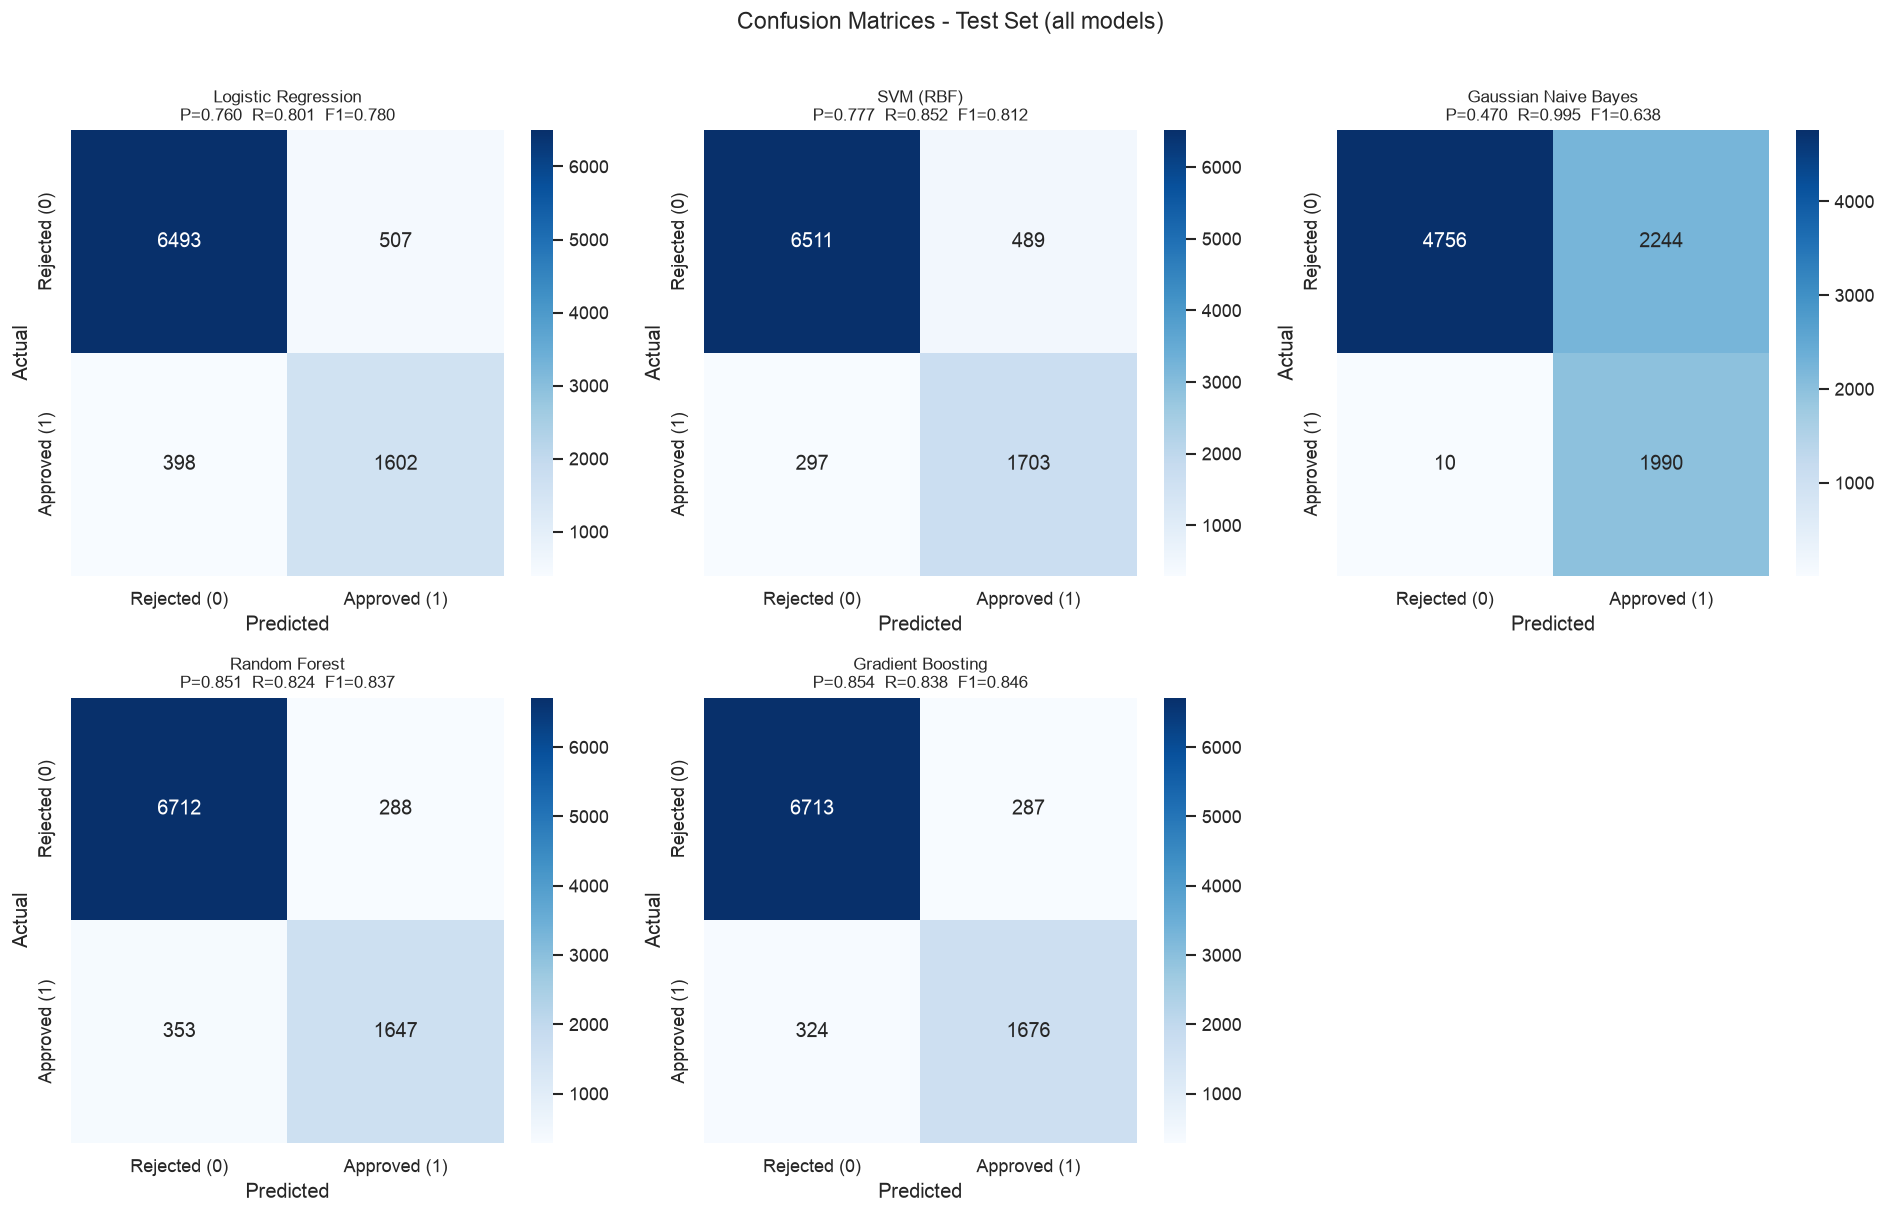

In [28]:
fig, axes = plt.subplots(2, 3, figsize=(16, 10))
axes_flat = axes.flatten()

for i, (name, pipeline) in enumerate(models.items()):
    scores = get_scores(pipeline, X_test)
    preds  = (scores >= best_thresholds[name]).astype(int)
    cm     = confusion_matrix(y_test, preds)

    row = results_df[results_df['Model'] == name].iloc[0]
    subtitle = f'P={row["Precision"]:.3f}  R={row["Recall"]:.3f}  F1={row["F1"]:.3f}'

    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', ax=axes_flat[i],
                xticklabels=['Rejected (0)', 'Approved (1)'],
                yticklabels=['Rejected (0)', 'Approved (1)'])
    axes_flat[i].set_title(f'{name}\n{subtitle}', fontsize=10)
    axes_flat[i].set_xlabel('Predicted')
    axes_flat[i].set_ylabel('Actual')

axes_flat[-1].set_visible(False)  # hide unused 6th subplot
plt.suptitle('Confusion Matrices - Test Set (all models)', fontsize=14, y=1.01)
plt.tight_layout()
plt.savefig(str(PLOTS_DIR / 'confusion_matrices_all.png'), bbox_inches='tight')
plt.show()

## 7. PR-AUC Curves - All Models

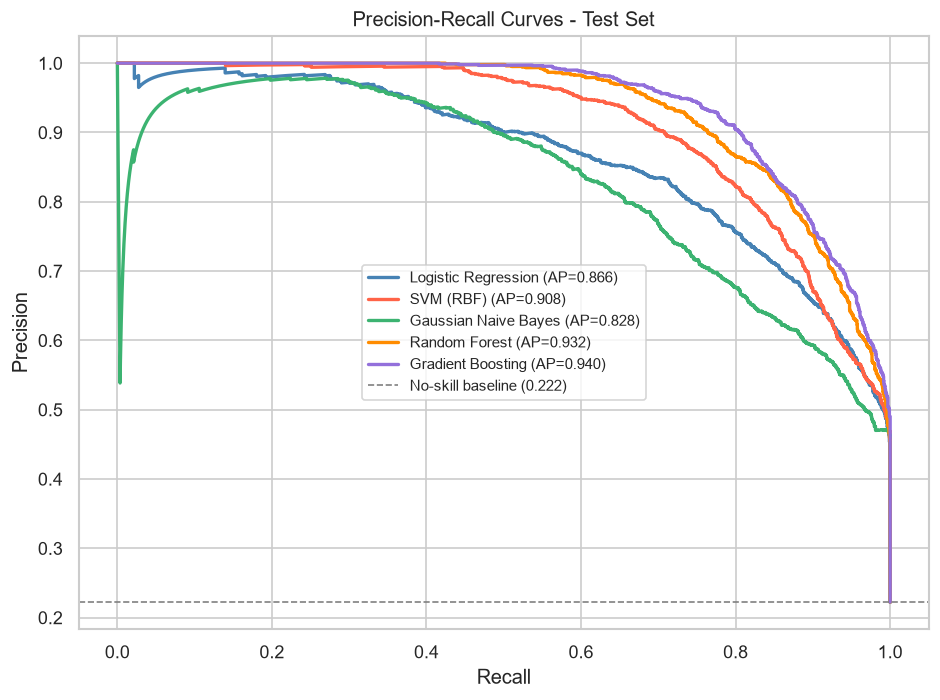

In [10]:
fig, ax = plt.subplots(figsize=(8, 6))
colors = ['steelblue', 'tomato', 'mediumseagreen', 'darkorange', 'mediumpurple']

for (name, pipeline), color in zip(models.items(), colors):
    scores    = get_scores(pipeline, X_test)
    prec, rec, _ = precision_recall_curve(y_test, scores)
    ap        = average_precision_score(y_test, scores)
    ax.plot(rec, prec, lw=2, color=color, label=f'{name} (AP={ap:.3f})')

ax.axhline(y_test.mean(), color='gray', linestyle='--', lw=1,
           label=f'No-skill baseline ({y_test.mean():.3f})')
ax.set_xlabel('Recall')
ax.set_ylabel('Precision')
ax.set_title('Precision-Recall Curves - Test Set')
ax.legend(fontsize=9)
plt.tight_layout()
plt.savefig(str(PLOTS_DIR / 'pr_curves_all.png'))
plt.show()

## 8. Model Complexity, Interpretability & Computational Cost

| Model | Interpretability | Complexity | Training Cost | Notes |
|---|---|---|---|---|
| Logistic Regression | High - coefficients directly readable | Low | Fast (seconds) | Linear boundary; struggles with non-linear patterns |
| SVM (RBF) | Low - kernel space not interpretable | Medium | Slow (minutes on 36K rows) | Strong margin-based classifier; no probability output by default |
| Gaussian Naive Bayes | Medium - per-feature likelihoods | Very low | Fastest | Independence assumption violated by OHE features; high recall but low precision |
| Random Forest | Medium - feature importances available | High | Moderate (400 trees) | Robust; averages many trees; less prone to overfitting than single DT |
| Gradient Boosting | Low - ensemble of trees | High | Moderate | Sequential boosting captures complex patterns; selected only if it has the highest test-set F1 |


---
# Section 5.8: Qualitative Analysis & Interpretation
## 9. Error Analysis - Best Model

We focus error analysis on the **primary model selected by the highest test-set F1 score** from Section 5.

This is a loan-**approval** model: `loan_status` reflects the bank's historical decision, not a verified default or repayment outcome. So:
- **False Positives**: predicted Approved, but the historical decision was Rejected. These are rejected applications whose characteristics resemble historically approved applications.
- **False Negatives**: predicted Rejected, but the historical decision was Approved. These are approved applications whose characteristics resemble historically rejected applications.


In [11]:
# Select the primary model using TEST-SET performance from Section 5.
# results_df is already sorted from highest to lowest F1 score.
best_row = results_df.iloc[0]
best_model_name = best_row['Model']
best_selection_score = best_row[SELECTION_METRIC]

best_pipeline = models[best_model_name]
best_t        = best_thresholds[best_model_name]

scores_test = get_scores(best_pipeline, X_test)
preds_test  = (scores_test >= best_t).astype(int)

X_test_reset = X_test.reset_index(drop=True)
y_test_reset = y_test.reset_index(drop=True)

fp_mask = (preds_test == 1) & (y_test_reset == 0)  # False Positives
fn_mask = (preds_test == 0) & (y_test_reset == 1)  # False Negatives
tp_mask = (preds_test == 1) & (y_test_reset == 1)  # True Positives
tn_mask = (preds_test == 0) & (y_test_reset == 0)  # True Negatives

print(
    f'Primary model (test-set {SELECTION_METRIC}-selected): '
    f'{best_model_name} ({SELECTION_METRIC}={best_selection_score:.4f}, '
    f'threshold={best_t:.4f})'
)
print(f'True Positives  (correct approvals)  : {tp_mask.sum():,}')
print(f'True Negatives  (correct rejections) : {tn_mask.sum():,}')
print(f'False Positives (wrong approvals)    : {fp_mask.sum():,}')
print(f'False Negatives (wrong rejections)   : {fn_mask.sum():,}')


Primary model (test-set F1-selected): Gradient Boosting (F1=0.8458, threshold=0.4147)
True Positives  (correct approvals)  : 1,676
True Negatives  (correct rejections) : 6,713
False Positives (wrong approvals)    : 287
False Negatives (wrong rejections)   : 324


In [12]:
# Sample false positives - loans predicted approved but were rejected
print('=== False Positives (predicted Approved, actually Rejected) ===')
display(X_test_reset[fp_mask].head(5))

=== False Positives (predicted Approved, actually Rejected) ===


,person_age,person_gender,person_education,person_income,person_emp_exp,person_home_ownership,loan_amnt,loan_intent,loan_int_rate,loan_percent_income,cb_person_cred_hist_length,credit_score,previous_loan_defaults_on_file
112,35.0,female,Bachelor,40861.0,11,RENT,7600.0,VENTURE,15.27,0.19,6.0,624,No
117,30.0,male,Associate,28387.0,9,RENT,3250.0,VENTURE,14.11,0.11,7.0,646,No
172,22.0,male,Associate,15013.0,0,MORTGAGE,1500.0,EDUCATION,14.84,0.10,3.0,688,No
202,26.0,male,Master,157279.0,3,MORTGAGE,35000.0,PERSONAL,18.25,0.22,4.0,693,No
203,23.0,male,Associate,59480.0,4,RENT,4800.0,EDUCATION,11.36,0.08,4.0,577,No


In [13]:
# Sample false negatives - loans predicted rejected but were approved
print('=== False Negatives (predicted Rejected, actually Approved) ===')
display(X_test_reset[fn_mask].head(5))

=== False Negatives (predicted Rejected, actually Approved) ===


,person_age,person_gender,person_education,person_income,person_emp_exp,person_home_ownership,loan_amnt,loan_intent,loan_int_rate,loan_percent_income,cb_person_cred_hist_length,credit_score,previous_loan_defaults_on_file
74,24.0,female,High School,43833.0,5,RENT,8000.0,PERSONAL,12.12,0.18,4.0,658,No
110,26.0,male,Bachelor,140055.0,6,MORTGAGE,5000.0,VENTURE,11.01,0.04,3.0,653,No
145,24.0,female,Bachelor,85978.0,3,MORTGAGE,5000.0,EDUCATION,10.39,0.06,2.0,631,No
154,23.0,female,Associate,68223.0,1,MORTGAGE,15000.0,PERSONAL,11.26,0.22,2.0,607,No
165,25.0,female,Bachelor,83753.0,0,RENT,8500.0,HOMEIMPROVEMENT,6.92,0.10,4.0,644,No


### 9.1 False Positive Profile

Compare the average feature values of false positives vs. true negatives (both historically rejected) to understand what makes a rejected applicant resemble a historically-approved profile to the model.


In [14]:
numeric_cols = ['person_age', 'person_income', 'person_emp_exp', 'loan_amnt',
                'loan_int_rate', 'loan_percent_income', 'cb_person_cred_hist_length', 'credit_score']
numeric_cols = [c for c in numeric_cols if c in X_test_reset.columns]

fp_profile = X_test_reset[fp_mask][numeric_cols].mean().rename('False Positive')
tn_profile = X_test_reset[tn_mask][numeric_cols].mean().rename('True Negative')
tp_profile = X_test_reset[tp_mask][numeric_cols].mean().rename('True Positive')
fn_profile = X_test_reset[fn_mask][numeric_cols].mean().rename('False Negative')

profile_df = pd.concat([tp_profile, fp_profile, tn_profile, fn_profile], axis=1).round(2)
print('Mean feature values by prediction outcome:')
display(profile_df)

Mean feature values by prediction outcome:


,True Positive,False Positive,True Negative,False Negative
person_age,27.36,28.14,27.85,27.91
person_income,55914.97,70841.76,86023.37,71162.16
person_emp_exp,5.03,5.76,5.52,5.41
loan_amnt,11404.18,8821.00,9205.89,8232.29
loan_int_rate,13.12,13.34,10.34,11.00
loan_percent_income,0.22,0.14,0.12,0.13
cb_person_cred_hist_length,5.78,6.03,5.91,5.84
credit_score,626.33,632.27,633.19,648.74


## 10. Feature Importance Interpretation

In [16]:
with open(MODELS_DIR / 'feature_names.json') as f:
    feature_names = json.load(f)

def plot_importances(pipeline, model_name, feature_names, X_eval=None, y_eval=None,
                      top_n=15, save_path=None):
    """Plot the top feature importances for a fitted pipeline.

    Tree models with native `feature_importances_` (Random Forest) and linear models
    with `coef_` (Logistic Regression) use their built-in importance.
    HistGradientBoostingClassifier ("Gradient Boosting" here) exposes NEITHER --
    sklearn deliberately omits feature_importances_ for it -- so it falls back to
    permutation importance on `X_eval`/`y_eval`. This also has the side benefit of
    reporting importance on the original (pre-one-hot) columns, since the pipeline's
    preprocessor runs inside `pipeline.predict`/`pipeline.score`.
    """
    clf = pipeline.named_steps['clf']

    if hasattr(clf, 'feature_importances_'):
        importances = clf.feature_importances_
        names = feature_names
    elif hasattr(clf, 'coef_'):
        importances = np.abs(clf.coef_[0])
        names = feature_names
    else:
        if X_eval is None or y_eval is None:
            print(f'{model_name}: no native feature importances, and no eval data given for permutation importance.')
            return
        perm = permutation_importance(
            pipeline, X_eval, y_eval,
            scoring='average_precision', n_repeats=10,
            random_state=SEED, n_jobs=-1,
        )
        importances = perm.importances_mean
        names = list(X_eval.columns)  # raw columns -- preprocessing lives inside the pipeline

    imp_df = pd.DataFrame({'feature': names, 'importance': importances})
    imp_df = imp_df.sort_values('importance', ascending=False).head(top_n)

    fig, ax = plt.subplots(figsize=(8, max(4, top_n * 0.35)))
    ax.barh(imp_df['feature'][::-1], imp_df['importance'][::-1], color='steelblue', edgecolor='white')
    ax.set_title(f'{model_name} - Top {top_n} Feature Importances')
    ax.set_xlabel('Importance')
    plt.tight_layout()
    if save_path:
        plt.savefig(save_path)
    plt.show()


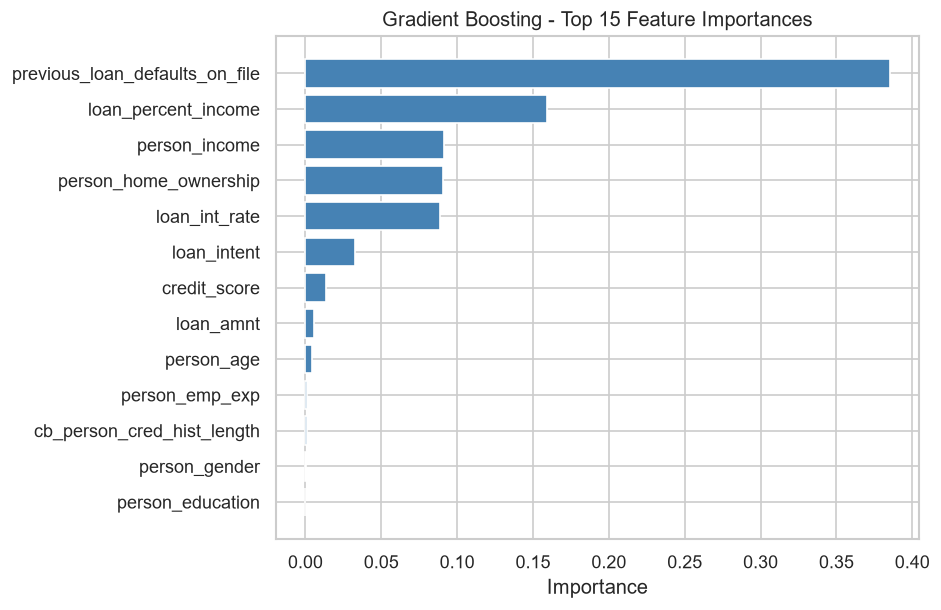

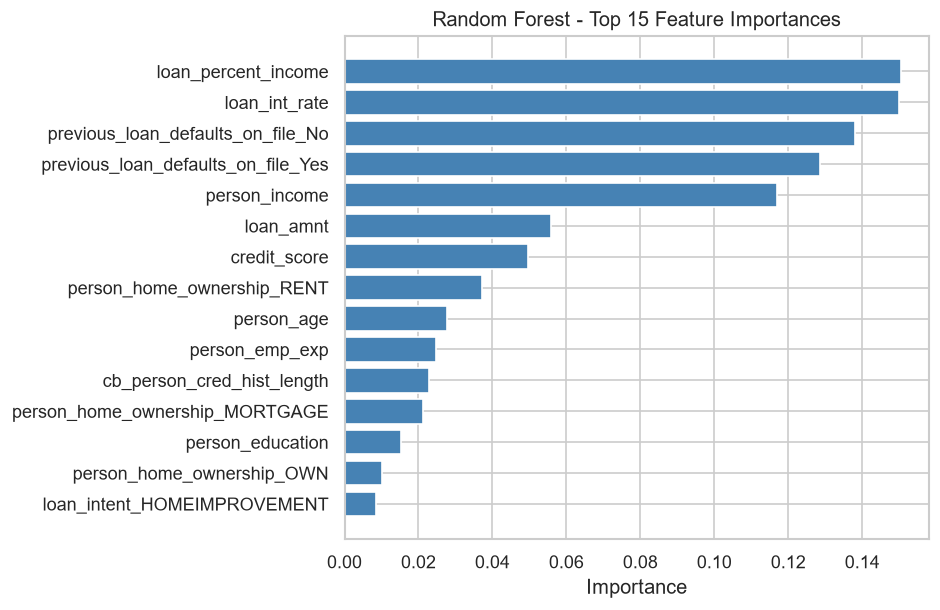

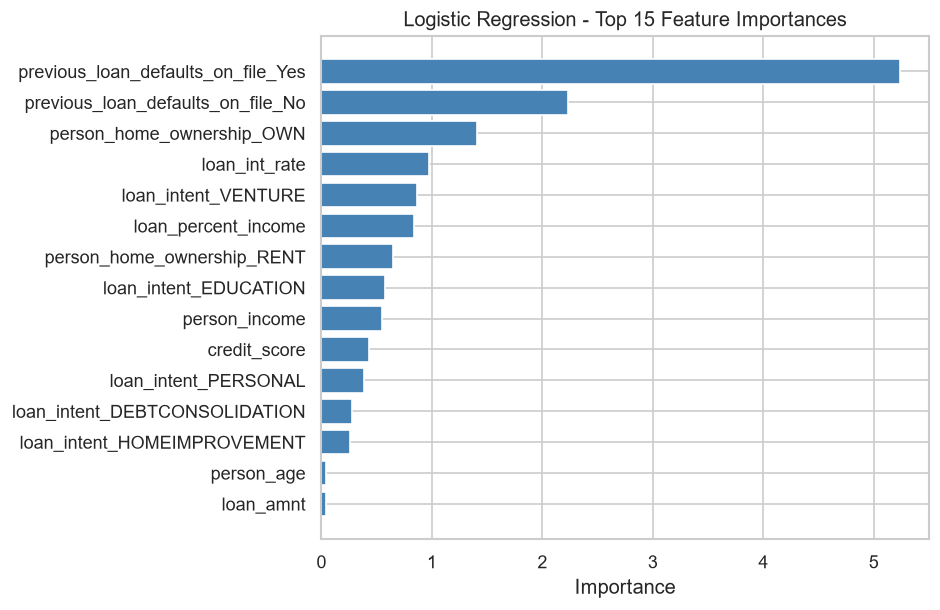

In [17]:
for name in ['Gradient Boosting', 'Random Forest', 'Logistic Regression']:
    slug = name.lower().replace(' ', '_').replace('(', '').replace(')', '')
    plot_importances(
        models[name], name, feature_names,
        X_eval=X_test, y_eval=y_test,   # used only for GB's permutation-importance fallback
        save_path=str(PLOTS_DIR / f'importance_{slug}.png')
    )


## 11. Why Some Models Performed Better Than Others

**Gradient Boosting** likely performed best because it builds trees sequentially: each tree corrects the errors of the previous one. This lets it capture complex, non-linear interactions between features (e.g. the interaction between `credit_score`, `loan_percent_income`, and `previous_loan_defaults_on_file`) that a linear model can't represent as directly. (The permutation-importance results above are consistent with this, but performance alone doesn't prove this is *the* mechanism: regularisation strength and how each model handles the categorical encoding likely also play a role.)

**Random Forest** performed second-best. It averages many independent trees (bagging), which reduces variance compared to a single decision tree. It trails Gradient Boosting because each tree is built independently rather than correctively.

**SVM (RBF)** performed reasonably but was the slowest to train. The RBF kernel maps data to a higher-dimensional space to find a margin, and it is sensitive to feature scaling. Its `decision_function` score is not a calibrated probability, which limits how the score can be *interpreted* (e.g. as "70% likely approved") — it does not prevent threshold tuning, since the threshold is chosen directly on that score (Section 4).

**Logistic Regression** is a linear model. It can only draw a straight decision boundary in the feature space. The loan approval decision is not linearly separable, which is reflected in its lower test-set classification performance. It is, however, the most interpretable: coefficients directly show which features push toward approval.

**Gaussian Naive Bayes** performs poorly in precision despite achieving high recall. This is because it assumes all features are independent, which is violated here. The one-hot encoded categorical variables (e.g. `loan_intent`) are by construction correlated with each other. As a result, the model overestimates the posterior probability of approval.

## 12. Final Comparison Table (for the Report)

In [18]:
print('Final Test Set Results -> copy into report Table:')
print(results_df.to_string(index=False))

Final Test Set Results -> copy into report Table:
               Model  Threshold  Accuracy  Balanced Accuracy  Precision  Recall       F1   PR-AUC
   Gradient Boosting     0.4147  0.932111           0.898500   0.853795  0.8380 0.845824 0.940169
       Random Forest     0.3980  0.929778           0.896107   0.846505  0.8355 0.840966 0.932336
           SVM (RBF)    -0.3029  0.916778           0.877214   0.817030  0.8060 0.811477 0.908397
 Logistic Regression     0.4175  0.896222           0.866143   0.744271  0.8120 0.776662 0.865691
Gaussian Naive Bayes     0.9933  0.749556           0.837214   0.470005  0.9950 0.638434 0.827961
